# Hierarchical Multiple Factor Analysis
## Some dependencies must be installed and loaded before installing and loading *FactoMineR* to compute HMFA

In [1]:
system("conda install -c conda-forge r-nloptr")

In [2]:
library(nloptr)

Warning message:
“package ‘nloptr’ was built under R version 4.4.3”


In [3]:
install.packages("lme4")

Updating HTML index of packages in '.Library'

Making 'packages.html' ...
 done



In [4]:
#install.packages("FactoMineR",dependencies=TRUE)

if (!require("devtools")) install.packages("devtools")
library(devtools)
install_github("husson/FactoMineR")


Loading required package: devtools

Loading required package: usethis

Skipping install of 'FactoMineR' from a github remote, the SHA1 (ea8e4d36) has not changed since last install.
  Use `force = TRUE` to force installation



In [5]:
install.packages("factoextra")

Updating HTML index of packages in '.Library'

Making 'packages.html' ...
 done



In [6]:
install.packages("ggplot2")

Updating HTML index of packages in '.Library'

Making 'packages.html' ...
 done



In [7]:
library("FactoMineR")

In [8]:
library("ggplot2")

In [9]:
library("factoextra")

Welcome! Want to learn more? See two factoextra-related books at https://goo.gl/ve3WBa



# Famié et al EBR data

The data contains 33 rows (individuals) and 37 columns (variables):
* The first column is a categorical variable: Cluster number.
* The 36 next columns are continuous variables. 

In [10]:
# Load your data
mydata <- read.csv("EBR_HMFA_2026.csv", sep = ";", row.names=1)

In [11]:
mydata

,Cluster,A1,A2,A3,A4,A5,A6,A7,A8,A9,⋯,IS3,IS4,IS5,IS6,IS7,IS8,IS9,IS10,IS11,IS12
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
10,Cluster1,98.636,117.210,131.881,124.836,138.745,116.847,131.247,129.493,136.170,⋯,2.004,2.262,2.321,2.317,2.286,2.759,2.912,2.884,3.407,3.170
14,Cluster1,86.684,92.457,129.367,76.898,86.348,125.711,112.371,93.825,123.187,⋯,1.534,1.770,1.705,2.014,2.400,2.027,2.461,2.723,2.672,2.836
16,Cluster1,57.734,68.430,69.459,66.596,109.147,88.377,72.297,84.918,81.578,⋯,2.011,1.995,2.077,2.526,2.435,2.267,2.621,3.186,2.870,3.212
19,Cluster1,72.638,73.417,99.600,111.077,106.471,120.499,128.190,115.577,124.529,⋯,1.760,2.114,1.886,2.049,2.406,2.219,2.560,2.828,2.838,2.894
20,Cluster1,119.379,167.574,170.446,178.992,202.542,218.826,205.679,189.384,200.333,⋯,2.038,2.390,2.104,2.711,2.559,2.123,2.935,2.906,2.672,3.199
27,Cluster1,100.846,146.284,103.315,119.236,197.582,75.647,104.668,250.477,104.244,⋯,1.850,1.748,1.910,1.901,2.345,2.249,2.516,2.880,3.357,3.134
29,Cluster1,102.895,137.768,141.244,132.392,190.141,171.359,141.988,188.450,192.417,⋯,1.907,2.547,2.330,2.220,3.133,2.423,2.864,3.125,3.107,3.605
37,Cluster1,70.328,76.348,56.824,83.061,76.318,74.522,93.139,80.188,84.426,⋯,1.321,1.909,1.727,1.720,2.493,2.072,2.428,2.747,2.554,2.952
41,Cluster1,93.854,111.461,90.476,118.121,102.118,72.192,153.540,107.201,135.924,⋯,2.435,3.100,2.814,2.684,3.163,2.973,3.933,3.585,3.793,3.605


The variables are organized in groups as follow:
1. First group - A group of categorical variables specifying the participant Cluster corresponding to the first column in the data table. In FactoMineR terminology, the arguments group = 1 is used to define the first column as a group.
2. Second group - A group of continuous variables, quantifying the strike amplitude as a function of each of 12 difficulty levels (optimal speed) : A1 = 0.967 to A2 = 2.499. These variables corresponds to the next 12 columns after the first group. *FactoMineR terminology: group = 12.*
3. Third group - A group of continuous variables quantifying the strike duration as a function of each of 12 difficulty levels (optimal speed) : D1 = 0.967 to D2 = 2.499. These variables corresponds to the next 12 columns after the first group. *FactoMineR terminology: group = 12.*
4. Fourth group - A group of continuous variables quantifying the strike impact speed as a function of each of 12 difficulty levels (optimal speed) : IS1 = 0.967 to IS2 = 2.499. These variables corresponds to the next 12 columns after the first group. *FactoMineR terminology: group = 12.*


In [12]:
hierar <- list(c(1,12,12,12), c(1,3))

In summary:
* We have 4 groups of variables, which can be specified to the FactoMineR as follow: group
= c(1, 12, 12, 12).
* These groups can be named as follow: name.group = c("cluster", "amplitude", "duration",
"impact_speed").
* Among the 4 groups of variables, one is categorical and three groups contain continuous
variables. It's recommended, to standardize the continuous variables during the analysis.
Standardization makes variables comparable, in the situation where the variables are
measured in different units. In FactoMineR, the argument type = "s" specifies that a given
group of variables should be standardized. If you don't want standardization, use type = "c".
To specify categorical variables, type = "n" is used. In our example, we'll use type c("n",
"s", "s", "s").

In [13]:
my.res.hmfa <- HMFA(mydata, H = hierar, type=c("n",rep("s",3)), graph = FALSE)

In [14]:
my.res.hmfa

**Results of the Hierarchical Multiple Factor Analysis (HMFA)**

There are 33 individuals

*Results are available in the following objects :

  name          description                              
1 "$eig"        "eigenvalues"                            
2 "$group"      "results for all the groups"             
3 "$ind"        "results for the individuals"            
4 "$partial"    "partial coordinates for the individuals"
5 "$quanti.var" "results for the quantitative variables" 
6 "$quali.var"  "results for the categorical variables"  

Warning message in geom_bar(stat = "identity", fill = barfill, color = barcolor, :
“Ignoring empty aesthetic: `width`.”


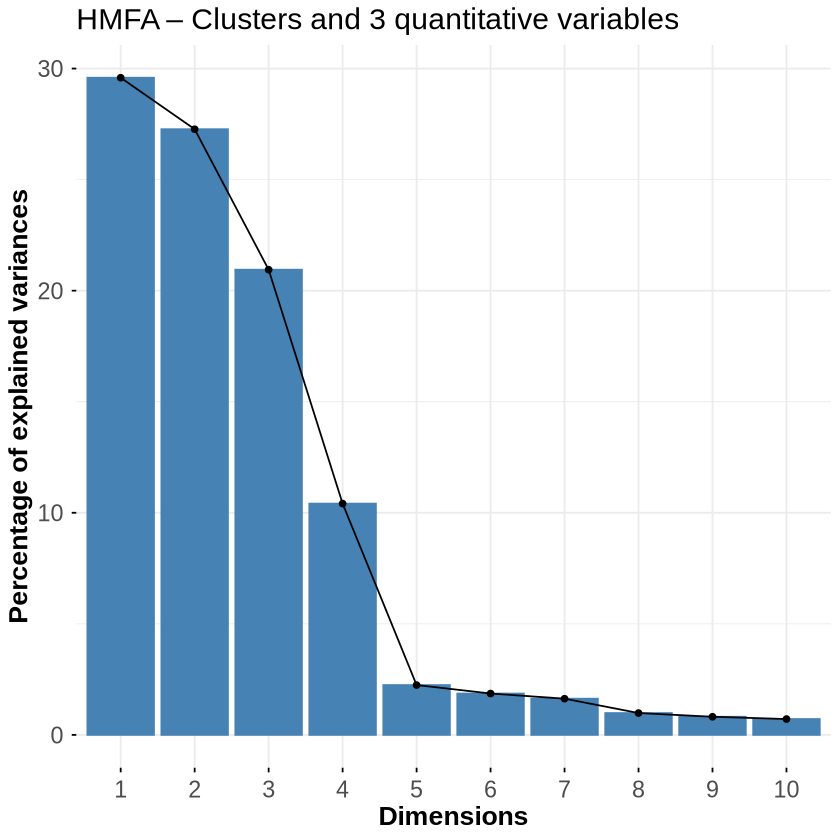

In [15]:
fviz_screeplot(my.res.hmfa, cex = 2) +  theme(
    axis.text = element_text(size = 14),
    axis.title = element_text(size = 16, face = "bold"),
    plot.title = element_text(size = 18)
  ) +
  ggtitle("HMFA – Clusters and 3 quantitative variables")

## Contribution of the continuous variables to the HMFA Dimensions

In [16]:
var_contrib <- get_hmfa_var(my.res.hmfa)
print(var_contrib$contrib)

         Dim.1        Dim.2      Dim.3       Dim.4        Dim.5
A1   2.4386273 1.144435e-01 0.86944198 0.003706345 5.401307e-01
A2   2.4517350 1.303757e-01 1.56633538 0.074730669 7.707805e-01
A3   2.0808878 6.613000e-03 2.38794738 0.005258793 1.081134e+00
A4   1.7962707 2.486492e-01 2.32483227 0.002281204 7.480328e+00
A5   1.0445758 4.628094e-02 2.46851468 0.358002219 7.541373e+00
A6   2.2580538 2.010042e-02 1.05359625 0.032727401 8.518931e+00
A7   1.6938648 5.008876e-01 2.02850830 0.026403059 1.073808e+00
A8   1.6004813 4.137592e-04 2.60197423 0.015880972 1.000588e+00
A9   1.9755385 3.676692e-01 1.99845943 0.101432656 6.864734e+00
A10  2.0193678 9.662989e-01 1.74414752 0.026798851 4.986726e-01
A11  1.3785765 3.995998e-01 2.62237868 0.155344615 6.115842e+00
A12  1.4559152 8.149810e-01 1.38366482 0.008173022 2.356708e+00
D1   1.5488093 4.083500e-01 0.99292186 3.377434524 2.284665e+00
D2   1.4224136 4.004013e-03 2.46515705 1.942337532 5.381296e+00
D3   0.6077458 8.348744e-02 2.68439214 3

## Contribution of the individuals to the HMFA Dimensions

In [17]:
ind_contrib <- get_hmfa(my.res.hmfa)
ind_contrib

Hierarchical Multiple Factor Analysis results for individuals 
  Name       Description                      
1 "$coord"   "Coordinates"                    
2 "$cos2"    "Cos2, quality of representation"
3 "$contrib" "Contributions"                  

In [18]:
print(ind_contrib$contrib)

          Dim.1      Dim.2       Dim.3       Dim.4       Dim.5
10  0.058737929 5.41936260  0.47323684  0.02102112  0.16671819
14  0.706835239 5.52582914  0.02202667  3.29972336  1.84327181
16  2.228890368 6.71104595  1.07155626  1.00710490  0.18614035
19  0.285527362 4.84623212  0.35302751  2.94396504  0.51844471
20  1.080258263 3.51646765  6.33112837  1.48945629  7.69284745
27  0.007638271 5.35009780  1.75014118  4.44635861 12.87940061
29  0.419911932 4.94997454  3.79083572  0.09063108  0.20445477
37  1.859739400 5.88513315  0.31294216  1.57296978  0.15846254
41  0.039118511 6.91728623  0.13290338 13.30050229  0.05712705
44  0.025421703 5.01097124  0.84726254  0.04889827  0.12006394
50  0.156177060 6.81492772  0.06936224  5.14437494  2.32927546
13  5.828697312 0.06767235  1.90438852 13.60556739  4.09325590
17  1.840557028 0.64247193  3.36587997  4.91614509  4.91580579
21  4.442082916 0.92248276  0.70279020  8.71666652  0.08623800
26  6.546416873 0.79006221  0.18052749  1.41150230  4.0

## HMFA Graphs

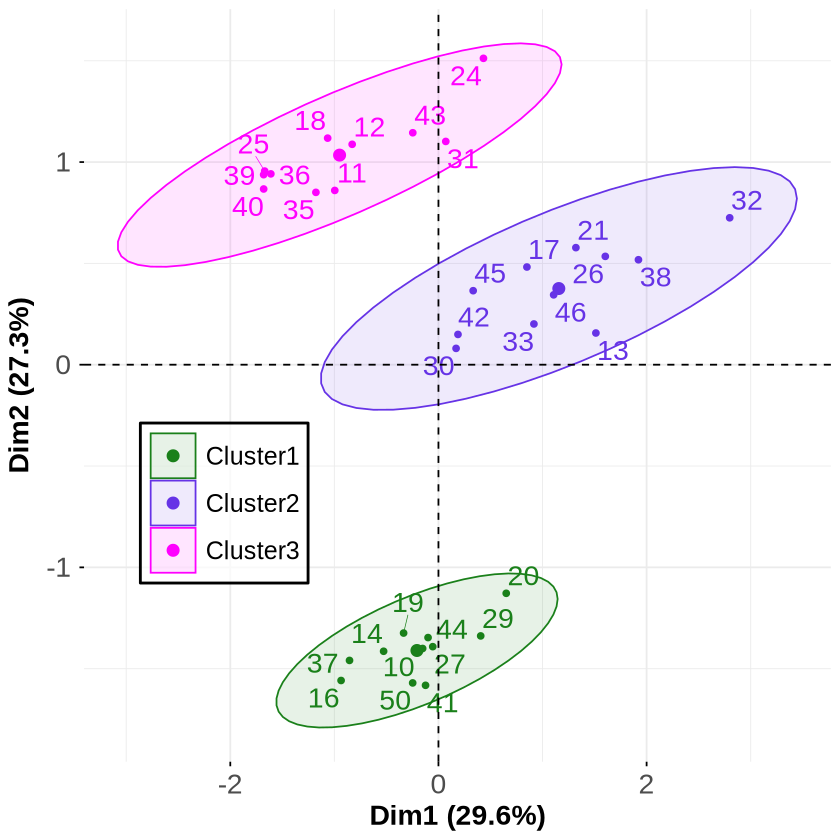

In [19]:
# Color individuals by groups, add concentration ellipses
# Remove labels: label = "none".
# Change color palette to "jco". See ?ggpubr::ggpar
grp2 <- as.factor(mydata[,1])

lv <- levels(grp2)
my_colors <- c("#1A801A", "#6633E6", "#FF00FF") [match(lv, lv)]

grp2 <- as.factor(mydata[,1])
p1_ind <- fviz_hmfa_ind(my.res.hmfa, habillage=grp2,   labelsize = 6, repel = TRUE, 
       addEllipses=TRUE, palette = my_colors, show.legend = F) +
  theme(
          axis.text  = element_text(size = 17),
    axis.title = element_text(size = 17, face = "bold"),
      legend.title = element_blank(),
      legend.text  = element_text(size = 15),
    legend.key.size = unit(1, "cm"),
    plot.title = element_blank(),
      legend.position = c(0.3, 0.45),   # inside the plot
    legend.justification = c(1, 1),
    legend.background = element_rect(
    fill = alpha("white", 0.7),   # background
    color = "black",              # <-- frame/border
    linewidth = 0.8,               # thickness of the frame
  )    
      )
print(p1_ind)

#png("HMFA_1_2.png", width=600,height=600)
#print(p2)
#dev.off()

Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.
ℹ The deprecated feature was likely used in the ggpubr package.
  Please report the issue at <https://github.com/kassambara/ggpubr/issues>.”
Warning message:
“`aes_string()` was deprecated in ggplot2 3.0.0.
ℹ Please use tidy evaluation idioms with `aes()`.
ℹ See also `vignette("ggplot2-in-packages")` for more information.
ℹ The deprecated feature was likely used in the factoextra package.
  Please report the issue at <https://github.com/kassambara/factoextra/issues>.”


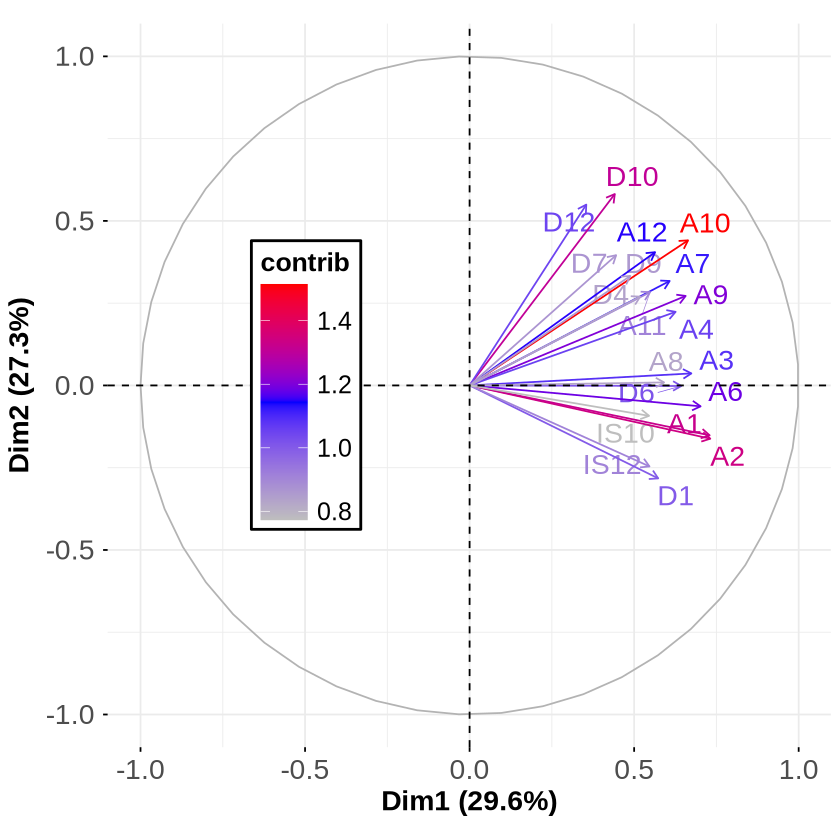

In [20]:
p1_var <- fviz_hmfa_var(my.res.hmfa, "quanti.var", repel = TRUE, col.var = "contrib", labelsize = 6, select.var = list(contrib = 20), gradient.cols = c("gray", "blue", "red")) + 
theme(
          axis.text  = element_text(size = 17),
    axis.title = element_text(size = 17, face = "bold"),
   legend.title = element_text(size = 16, face = "bold"),
      legend.text  = element_text(size = 15),
    legend.key.size = unit(1, "cm"),
    plot.title = element_blank(),
      legend.position = c(0.35, 0.7),   # inside the plot
    legend.justification = c(1, 1),
    legend.background = element_rect(
    fill = alpha("white", 1),   # background
    color = "black",              # <-- frame/border
    linewidth = 0.8               # thickness of the frame
  )    )

print(p1_var)

In [21]:
install.packages("patchwork")


Updating HTML index of packages in '.Library'

Making 'packages.html' ...
 done



In [22]:
library(patchwork)

In [23]:
# Combine the plots
# The '+' signs place them side-by-side
# Combine with a spacer in the middle
# We use 'plot_spacer()' and assign it a relative width
combined_plot <- p1_ind + plot_spacer() + p1_var + 
  plot_layout(widths = c(1, 0.1, 1)) &   # 0.1 is the width of the gap
  theme(aspect.ratio = 1)

# Save using ggsave or cowplot
ggsave("combined_figure_Dim1_2.png", combined_plot, width = 14, height = 7, units = "in")


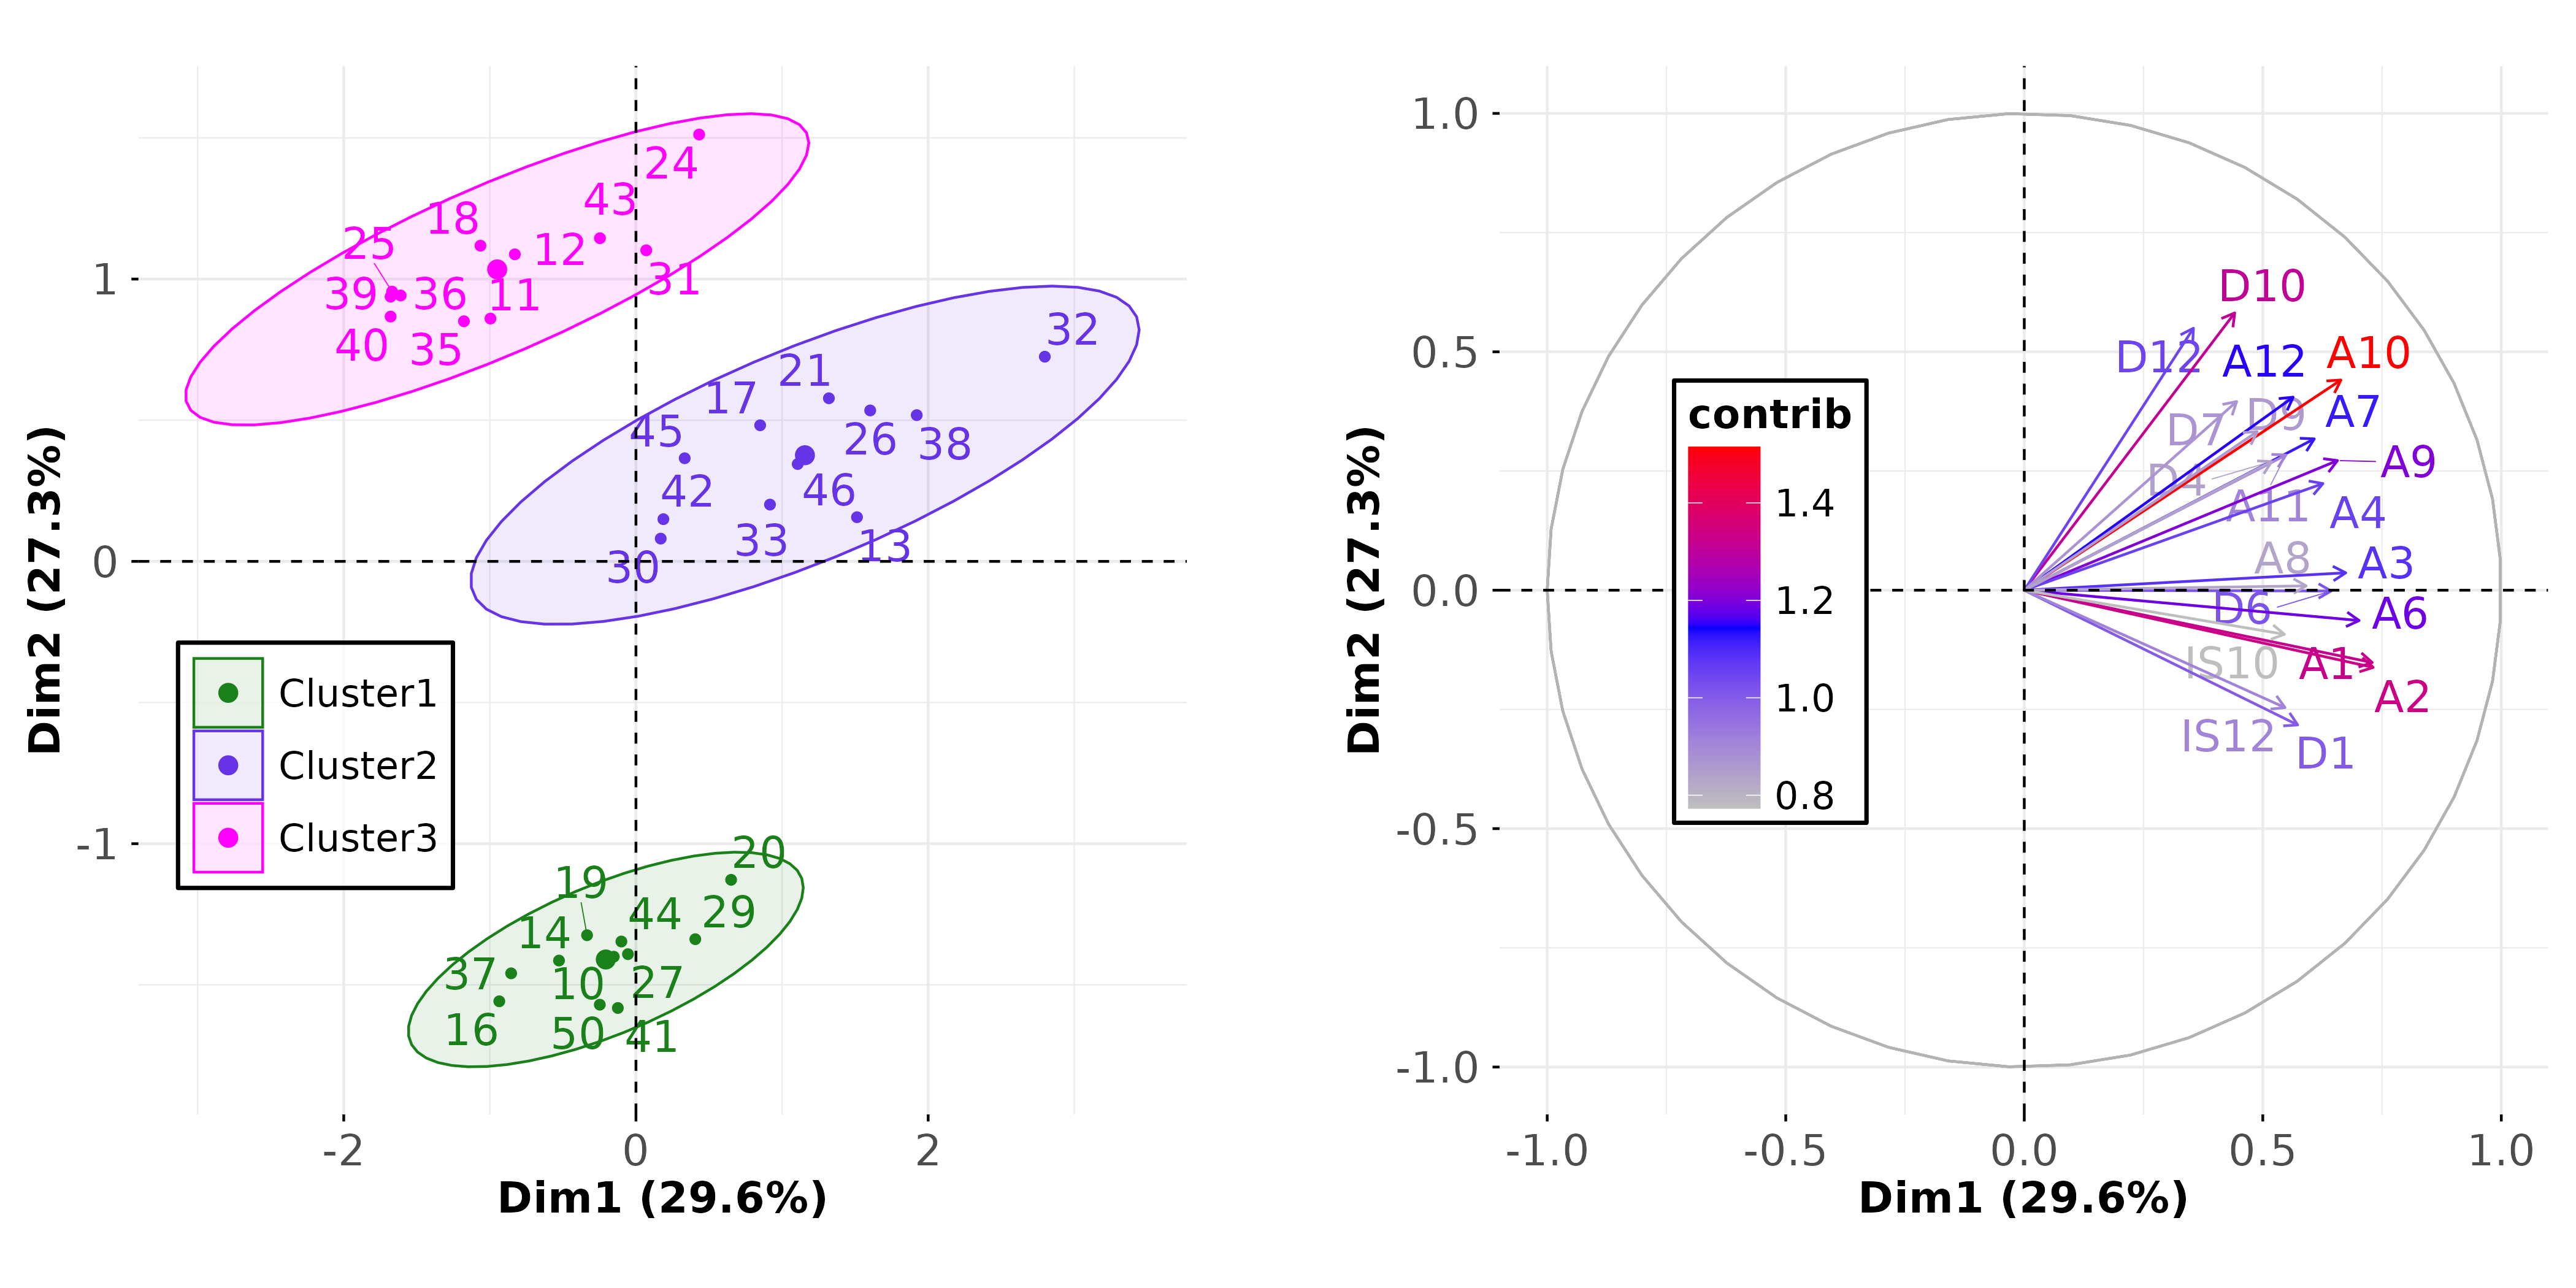

In [24]:
library(IRdisplay)
display_png(file = "combined_figure_Dim1_2.png")

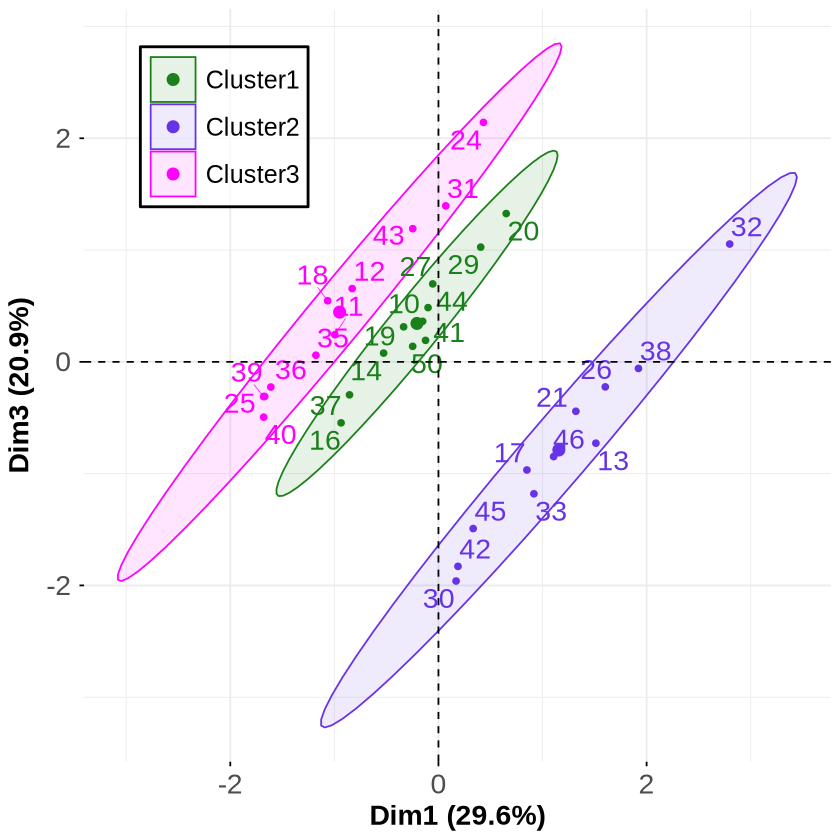

In [25]:

#grp2 <- as.factor(mydata[,1])

#lv <- levels(grp2)
#my_colors <- c("#1A801A", "#6633E6", "#FF00FF") [match(lv, lv)]

#grp2 <- as.factor(mydata[,1])

p2_ind <- fviz_hmfa_ind(my.res.hmfa, habillage=grp2, axes = c(1, 3),  labelsize = 6, repel = TRUE, 
       addEllipses=TRUE, palette = my_colors, show.legend = F) +
  theme(
          axis.text  = element_text(size = 17),
    axis.title = element_text(size = 17, face = "bold"),
      legend.title = element_blank(),
      legend.text  = element_text(size = 15),
    legend.key.size = unit(1, "cm"),
    plot.title = element_blank(),
      legend.position = c(0.3, 0.95),   # inside the plot
    legend.justification = c(1, 1),
    legend.background = element_rect(
    fill = alpha("white", 0.7),   # background
    color = "black",              # <-- frame/border
    linewidth = 0.8,               # thickness of the frame
  )    
      )
print(p2_ind)

#png("HMFA_1_3.png", width=600,height=600)
#print(p2_ind)
#dev.off()

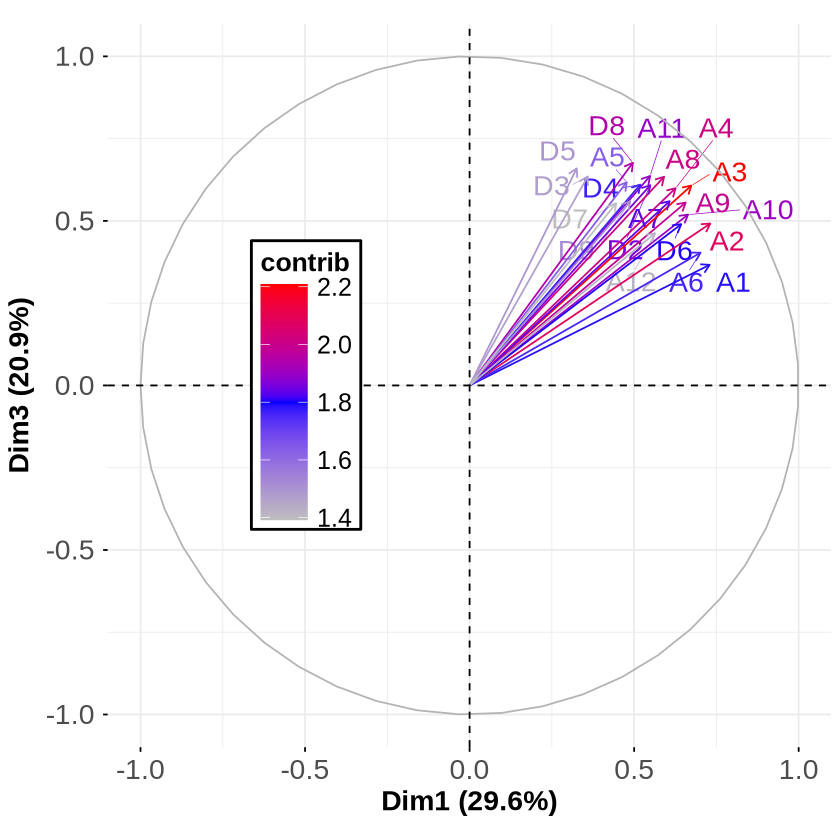

In [26]:
p2_var <- fviz_hmfa_var(my.res.hmfa, "quanti.var", repel = TRUE, col.var = "contrib", axes = c(1, 3), labelsize = 6, select.var = list(contrib = 20), gradient.cols = c("gray", "blue", "red")) + 
theme(
          axis.text  = element_text(size = 17),
    axis.title = element_text(size = 17, face = "bold"),
   legend.title = element_text(size = 16, face = "bold"),
      legend.text  = element_text(size = 15),
    legend.key.size = unit(1, "cm"),
    plot.title = element_blank(),
      legend.position = c(0.35, 0.7),   # inside the plot
    legend.justification = c(1, 1),
    legend.background = element_rect(
    fill = alpha("white", 1),   # background
    color = "black",              # <-- frame/border
    linewidth = 0.8               # thickness of the frame
  )    )

print(p2_var)

In [27]:
combined_plot2 <- p2_ind + plot_spacer() + p2_var + 
  plot_layout(widths = c(1, 0.1, 1)) &   # 0.1 is the width of the gap
  theme(aspect.ratio = 1)

# Save using ggsave or cowplot
ggsave("combined_figure_Dim1_3.png", combined_plot2, width = 14, height = 7, units = "in")

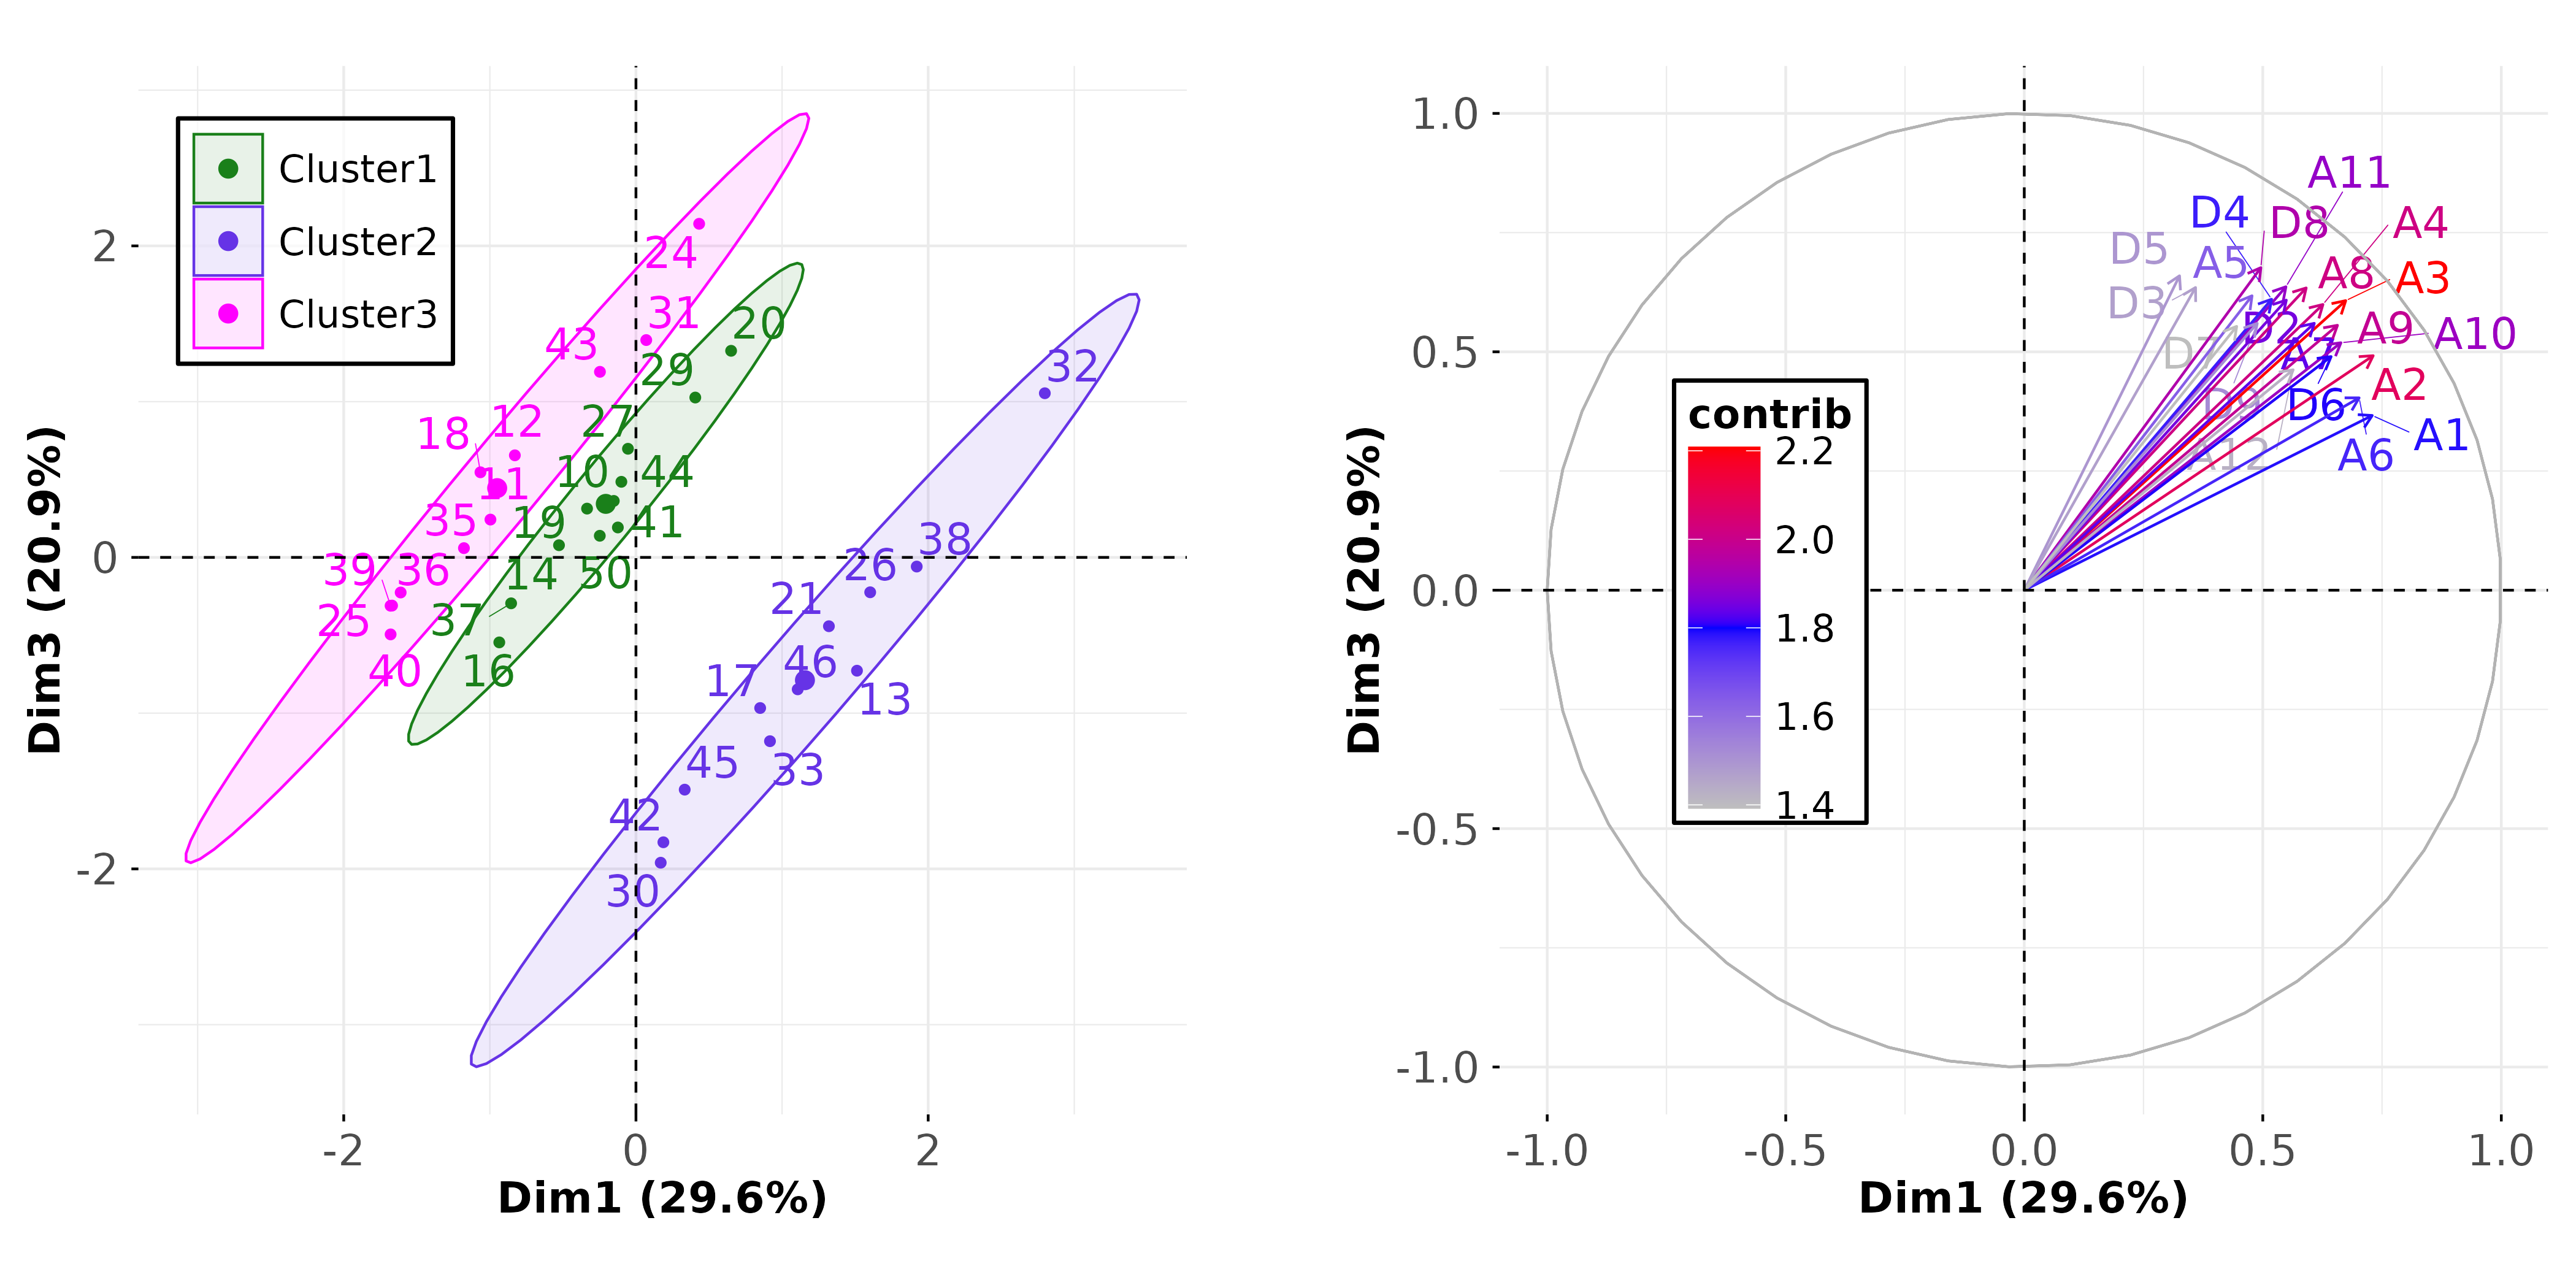

In [28]:
display_png(file = "combined_figure_Dim1_3.png")

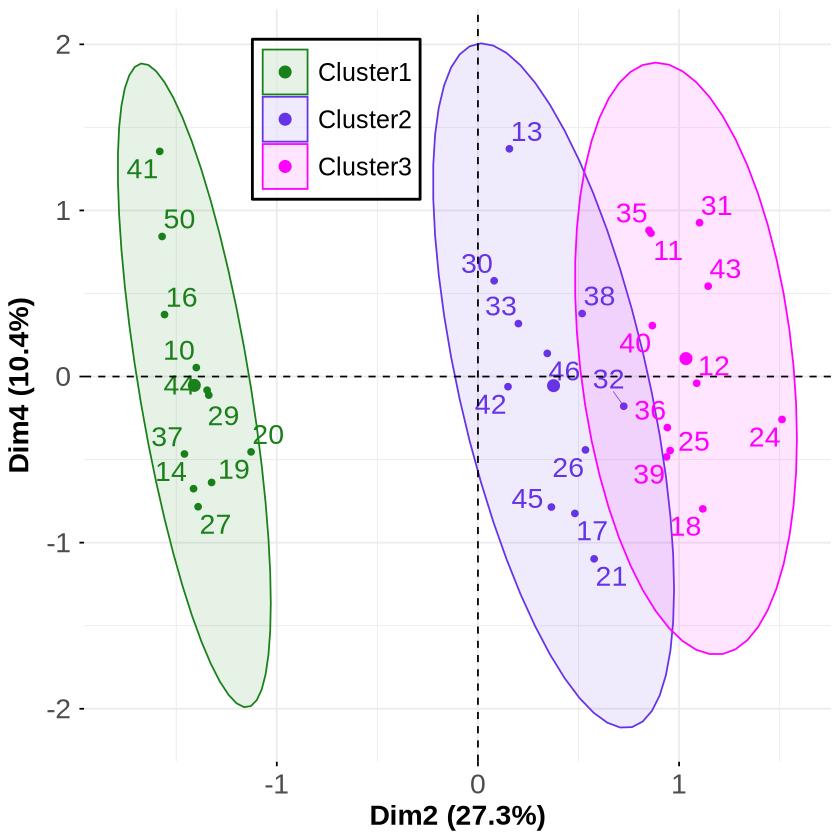

In [29]:
p3_ind <- fviz_hmfa_ind(my.res.hmfa, habillage=grp2, axes = c(2, 4),  labelsize = 6, repel = TRUE, 
       addEllipses=TRUE, palette = my_colors, show.legend = F) +
  theme(
          axis.text  = element_text(size = 17),
    axis.title = element_text(size = 17, face = "bold"),
      legend.title = element_blank(),
      legend.text  = element_text(size = 15),
    legend.key.size = unit(1, "cm"),
    plot.title = element_blank(),
      legend.position = c(0.45, 0.96),   # inside the plot
    legend.justification = c(1, 1),
    legend.background = element_rect(
    fill = alpha("white", 0.7),   # background
    color = "black",              # <-- frame/border
    linewidth = 0.8,               # thickness of the frame
  )    
      )
print(p3_ind)

#png("HMFA_2_4.png", width=600,height=600)
#print(p3_ind)
#dev.off()

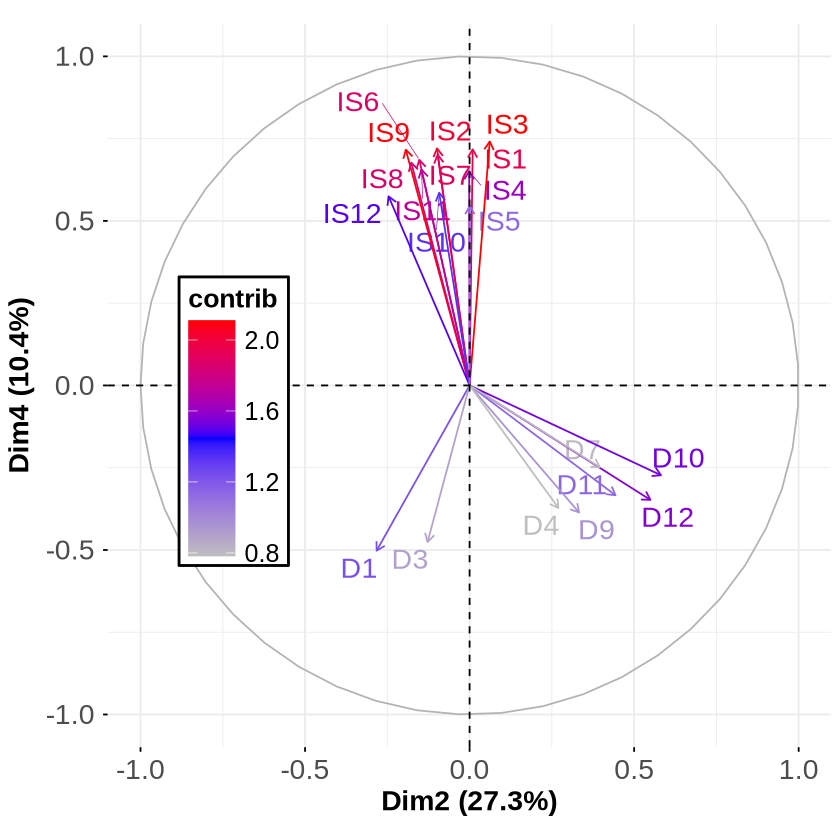

In [30]:
p3_var <- fviz_hmfa_var(my.res.hmfa, "quanti.var", repel = TRUE, col.var = "contrib", axes = c(2, 4), labelsize = 6, select.var = list(contrib = 20), gradient.cols = c("gray", "blue", "red")) + 
theme(
          axis.text  = element_text(size = 17),
    axis.title = element_text(size = 17, face = "bold"),
   legend.title = element_text(size = 16, face = "bold"),
      legend.text  = element_text(size = 15),
    legend.key.size = unit(1, "cm"),
    plot.title = element_blank(),
      legend.position = c(0.25, 0.65),   # inside the plot
    legend.justification = c(1, 1),
    legend.background = element_rect(
    fill = alpha("white", 1),   # background
    color = "black",              # <-- frame/border
    linewidth = 0.8               # thickness of the frame
  )    )

print(p3_var)

In [31]:
combined_plot3 <- p3_ind + plot_spacer() + p3_var + 
  plot_layout(widths = c(1, 0.1, 1)) &   # 0.1 is the width of the gap
  theme(aspect.ratio = 1)

# Save using ggsave or cowplot
ggsave("combined_figure_Dim2_4.png", combined_plot3, width = 14, height = 7, units = "in")

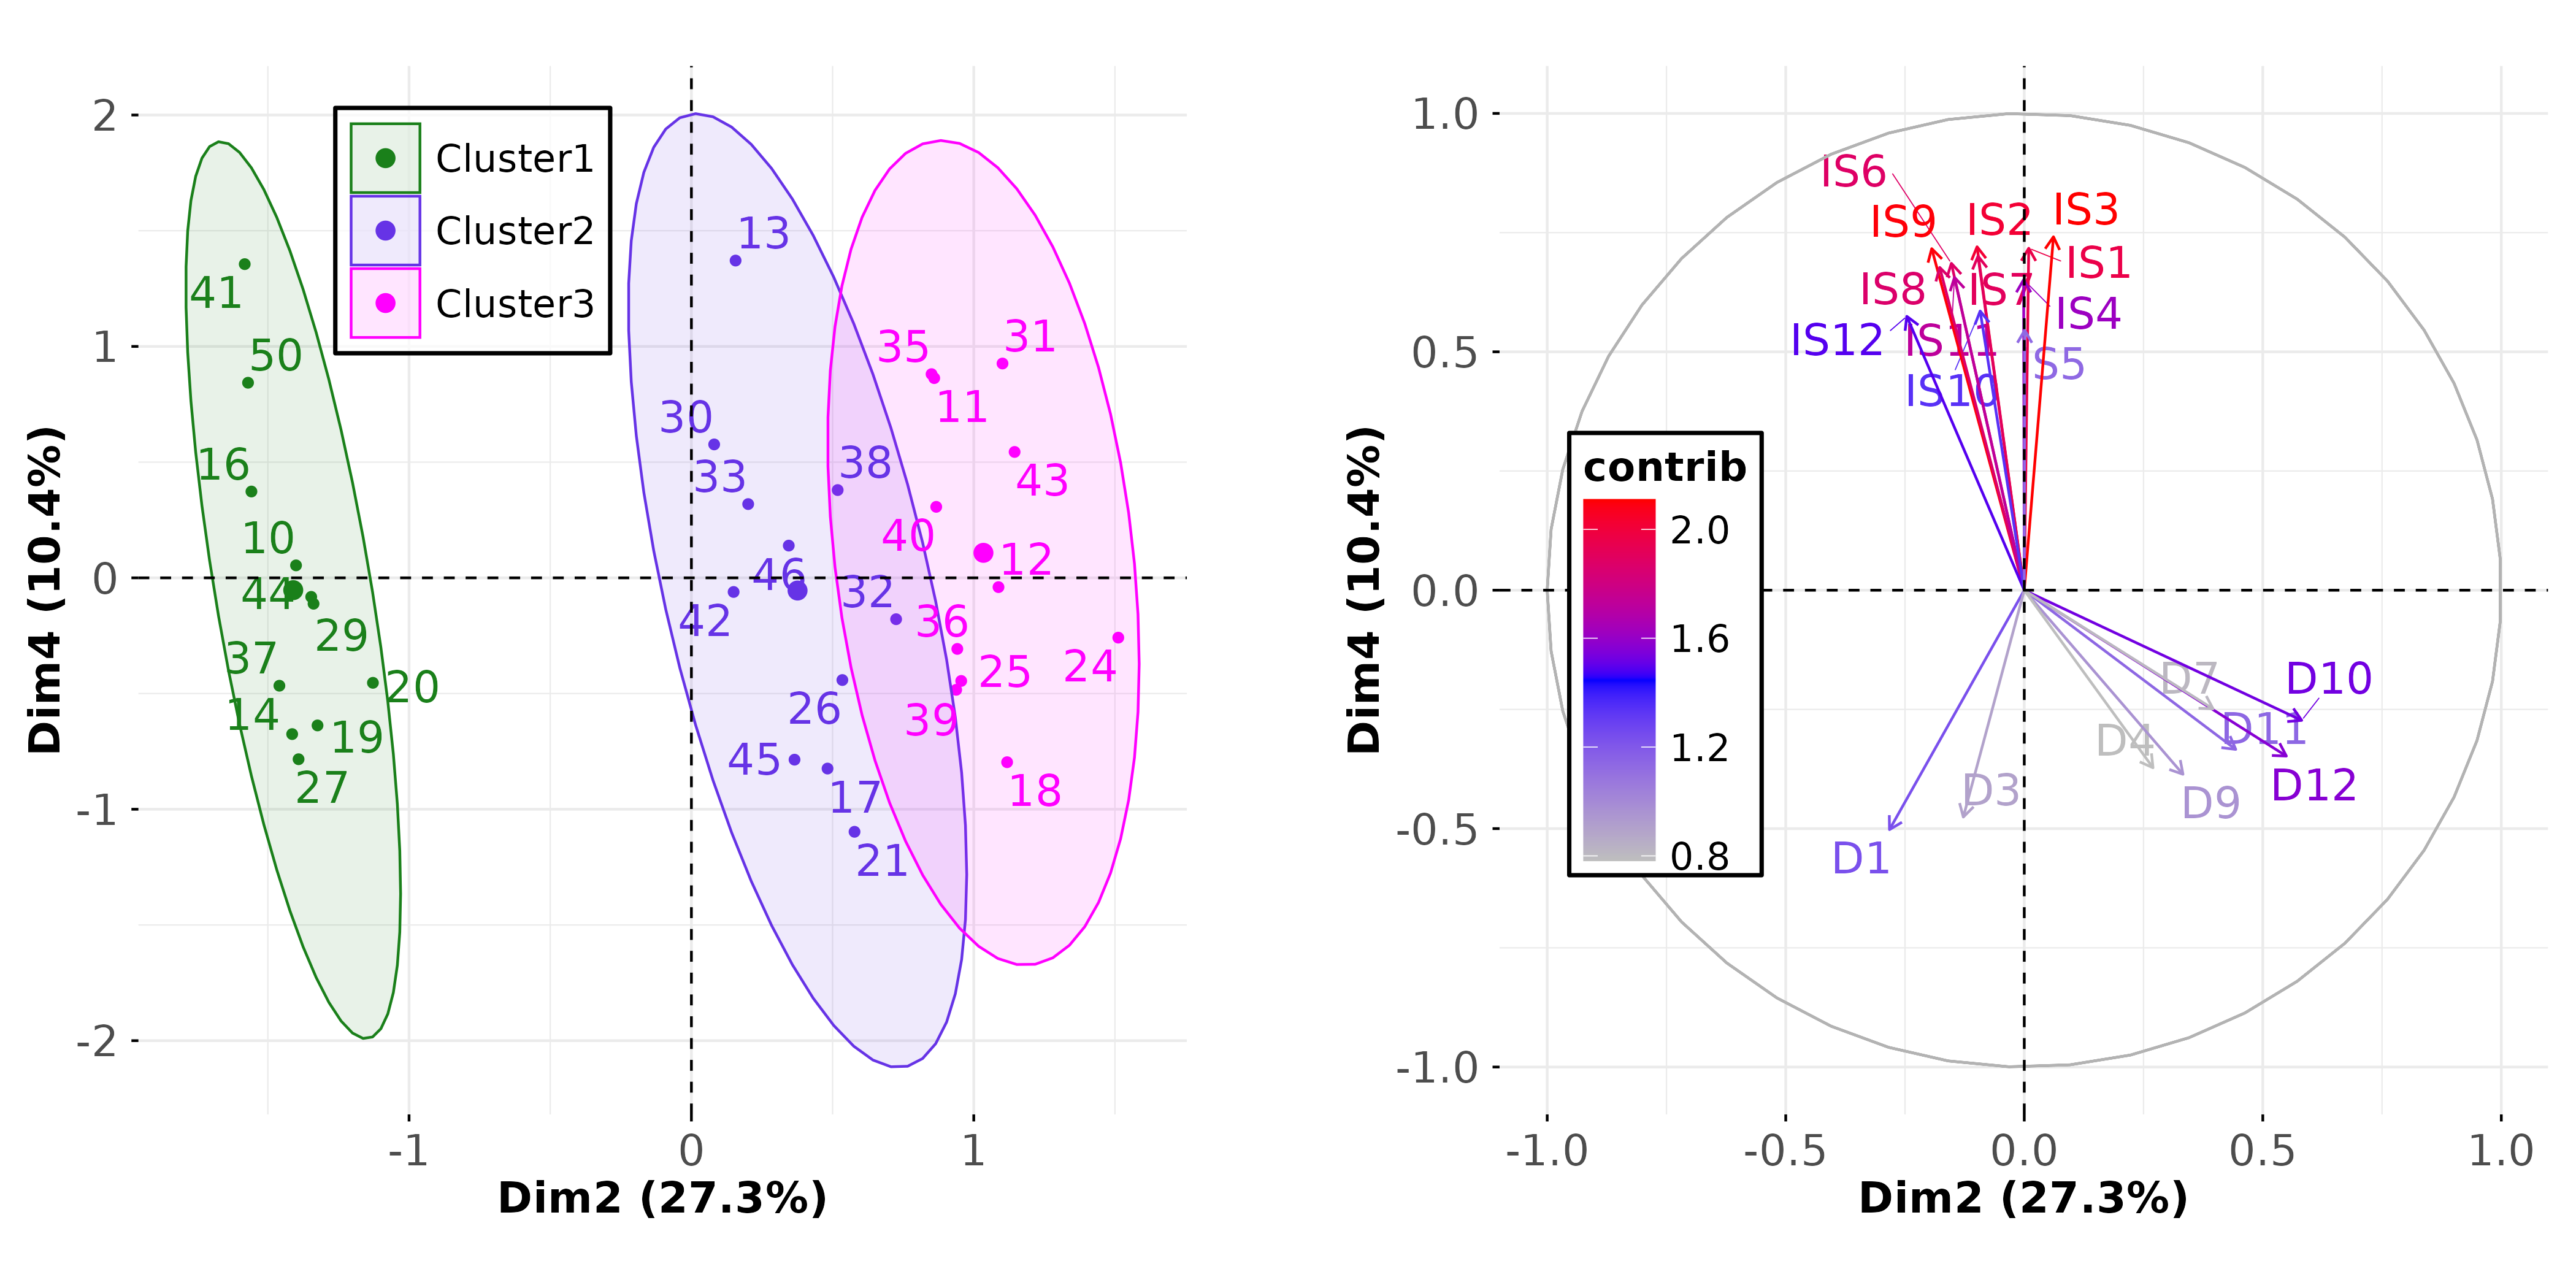

In [32]:
display_png(file = "combined_figure_Dim2_4.png")

## 3D interactive plot

In [33]:
install.packages("rgl")
library(rgl)

Updating HTML index of packages in '.Library'

Making 'packages.html' ...
 done

This build of rgl does not include OpenGL functions.  Use
 rglwidget() to display results, e.g. via options(rgl.printRglwidget = TRUE).



In [34]:
lv <- levels(grp2)
my_colors <- c("#1A801A", "#6633E6", "#FF00FF") [match(lv, lv)]
cols <- my_colors[grp2]

coords <- ind_contrib$coord[, c(1, 2, 3)]

plot3d(
    ind_contrib$coord[, 1:3],
    type = "s",
    radius = 0.07,
    col = cols,
    cex = 3
)



offset <- 0.3
text3d(
  ind_contrib$coord[,1] + offset,
  ind_contrib$coord[,2] ,
  ind_contrib$coord[,3] ,
  texts = rownames(ind_contrib$coord),
  cex = 1
)


# Determine the bottom Z plane
#z_bottom <- min(coords[,3])  # or any fixed value you prefer
z_bottom <- -2.2 

# Draw XY zero lines (Dim1 = 0, Dim2 = 0)
x_range <- range(coords[,1])
y_range <- range(coords[,2])
z_range <- range(coords[,3])


# Line along Y-axis at X = 0
segments3d(
  x = c(0, 0),
  y = y_range,
  z = c(z_bottom, z_bottom),
  col = "black",
  lwd = 1,
  lty = 3
)

# Line along X-axis at Y = 0
segments3d(
  x = x_range,
  y = c(0, 0),
  z = c(z_bottom, z_bottom),
   col = "black",
   lwd = 1,
  lty = 4
)

# Draw vertical lines from each point down to the bottom plane
for (i in 1:nrow(coords)) {
  segments3d(
    x = c(coords[i,1], coords[i,1]),
    y = c(coords[i,2], coords[i,2]),
    z = c(z_bottom, coords[i,3]),  # from bottom to point
    #col = "gray"
      col = cols[i],   # same color as the point
  lwd = 2
  )
}

In [35]:
#rglwidget()
# Render widget fullscreen
rglwidget(width = 900, height = 900)

HTML widgets cannot be represented in plain text (need html)

In [36]:
library(htmlwidgets)
w <- rglwidget()  # my widget
saveWidget(w, "fig_dim1_2_3.html")

In [118]:
lv <- levels(grp2)
my_colors <- c("#1A801A", "#6633E6", "#FF00FF") [match(lv, lv)]
cols <- my_colors[grp2]

coords <- ind_contrib$coord[, c(1, 2, 3)]
z_bottom <- -2.2  

x_range <- range(coords[,1])
y_range <- range(coords[,2])

# Generate forced tick positions
x_ticks <- pretty(x_range)
y_ticks <- pretty(y_range)

plot3d(
    coords,
    type = "s",
    radius = 0.07,
    col = cols,
    axes = FALSE,   
    xlab = "", ylab = "", zlab = "",
    xlim = range(x_ticks), # Match the plot box to the ticks
    ylim = range(y_ticks),
    zlim = c(z_bottom, max(coords[,3])+0.1) 
)

# Force the axis to use the calculated ticks
axis3d('x--', at = x_ticks, cex = 1.50)  
axis3d('y--', at = y_ticks, cex = 1.50)
axis3d('z-+', cex = 1.50)

title3d(xlab = "Dim 1", ylab = "Dim 2", zlab = "Dim 3", cex = 1.5)

offset <- 0.2
text3d(coords[,1] + offset, coords[,2] - offset/2, coords[,3] - offset/4,
       texts = rownames(coords), cex = 1.25)

# Floor Perimeter
lines3d(
    x = c(min(x_ticks), max(x_ticks), max(x_ticks), min(x_ticks), min(x_ticks)),
    y = c(min(y_ticks), min(y_ticks), max(y_ticks), max(y_ticks), min(y_ticks)),
    z = rep(z_bottom, 5),
    col = "black", lwd = 2
)

# Zero Lines
segments3d(x = c(0, 0), y = range(y_ticks), z = z_bottom, col = "black", lty = 3)
segments3d(x = range(x_ticks), y = c(0, 0), z = z_bottom, col = "black", lty = 4)

# Drop Lines
for (i in 1:nrow(coords)) {
  segments3d(x = c(coords[i,1], coords[i,1]), y = c(coords[i,2], coords[i,2]),
             z = c(z_bottom, coords[i,3]), col = cols[i], lwd = 2)
}

In [119]:
#rglwidget()
# Render widget fullscreen
rglwidget(width = 1200, height = 1200)

HTML widgets cannot be represented in plain text (need html)